In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
from tqdm import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

d:\Downloads\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\Downloads\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# preparation

In [21]:
path = "dataset"

## func

In [2]:
def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=None)
        
    mels = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=20)
    mels_db = librosa.power_to_db(mels, ref=np.max)
        
    zcr = librosa.feature.zero_crossing_rate(y)
        
    return np.hstack([
        np.mean(mels_db, axis=1), 
        np.std(mels_db, axis=1), 
        np.mean(zcr, axis=1), 
        np.std(zcr, axis=1)
    ])

In [3]:
def process_emotion_folders(audio_path):
    X, y = [], []
    
    emotion_dirs = [d for d in os.listdir(audio_path) if os.path.isdir(os.path.join(audio_path, d))]

    for emotion_label in tqdm(emotion_dirs, desc="Processing sounds"):
        emotion_path = os.path.join(audio_path, emotion_label)
        
        files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.wav', '.mp3'))]
        
        for file in files:
            file_path = os.path.join(emotion_path, file)
            
            features = extract_features(file_path)
            if features is not None:
                X.append(features)
                y.append(emotion_label)
                
    return np.array(X), np.array(y)

In [20]:
def convert_audio_to_images(source_dir, target_dir, n_mels=20):

    os.makedirs(target_dir, exist_ok=True)
    emotion_dirs = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

    for emotion_label in tqdm(emotion_dirs, desc="processing emotions"):
        source_emotion_path = os.path.join(source_dir, emotion_label)
        
        target_emotion_path = os.path.join(target_dir, emotion_label)
        os.makedirs(target_emotion_path, exist_ok=True)
        
        files = [f for f in os.listdir(source_emotion_path) if f.lower().endswith(('.wav', '.mp3'))]
    
        for file in files:
            file_path = os.path.join(source_emotion_path, file)
            new_file_name = file.rsplit('.', 1)[0] + '.png'
            save_path = os.path.join(target_emotion_path, new_file_name)
            
            y, sr = librosa.load(file_path, sr=22050)
                
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
            S_dB = librosa.power_to_db(S, ref=np.max)

            fig, ax = plt.subplots(figsize=(2, 2))
            ax.axis('off')
            fig.subplots_adjust(left=0, right=1, bottom=0, top=1) 

            librosa.display.specshow(S_dB, sr=sr, cmap='inferno', ax=ax)

            fig.savefig(save_path, format='png', dpi=100)
            plt.close(fig)

In [22]:
output_folder = "spectrograms" 
convert_audio_to_images(path, output_folder)

processing emotions: 100%|██████████| 3/3 [02:09<00:00, 43.03s/it]


## eda

In [6]:
data_info = {}

for sounds in os.listdir(path):
    sounds_folder = os.path.join(path, sounds)
    if os.path.isdir(sounds_folder):
        count = len(os.listdir(sounds_folder))
        data_info[sounds] = count

df_dist = pd.DataFrame(list(data_info.items()), columns=['Type', 'Count'])
df_dist = df_dist.sort_values(by='Count', ascending=False)
df_dist

,Type,Count
0,air vehicles,106
2,weapons,99
1,tank,79


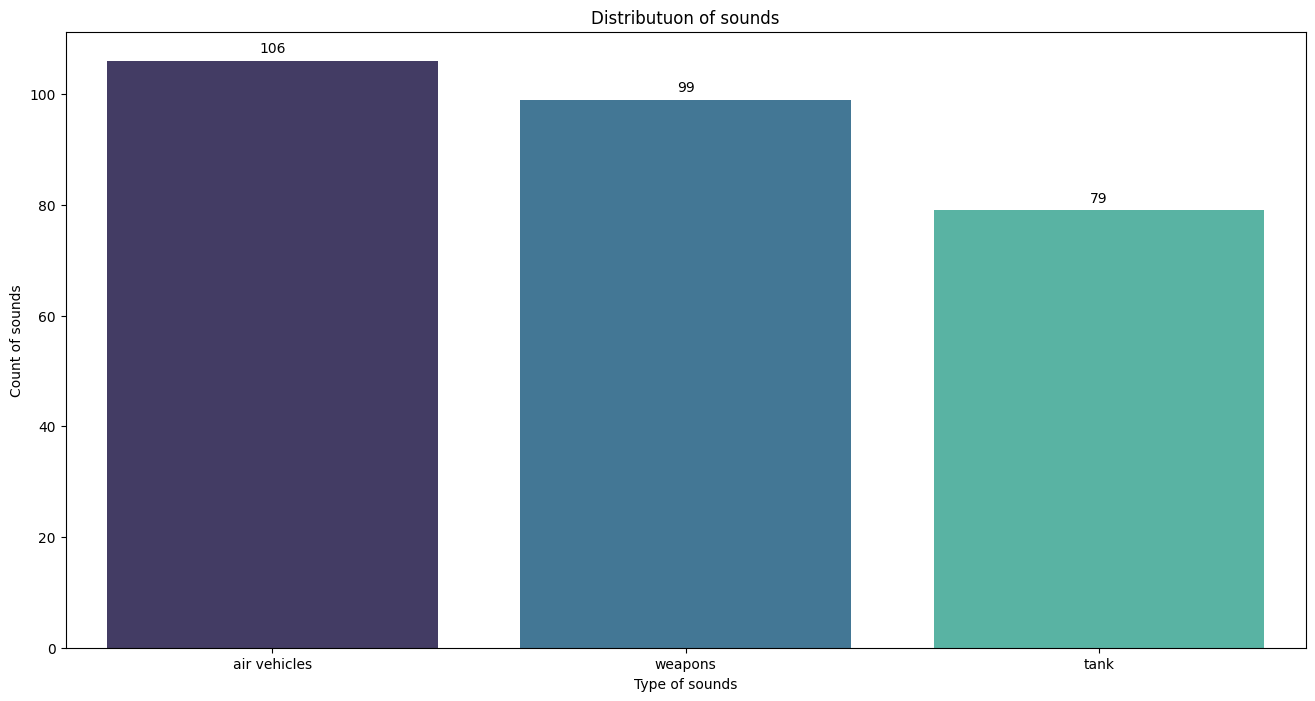

In [7]:
f, ax = plt.subplots(1, 1, figsize = (16, 8))

sns.barplot(
    data = df_dist,
    x = 'Type', 
    y = 'Count', 
    hue = 'Type',
    palette = 'mako',
    ax = ax,
    legend = False
    )

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

ax.set(title = 'Distributuon of sounds', xlabel = 'Type of sounds', ylabel = 'Count of sounds')
plt.show()

## preprocess

In [8]:
X_raw, y_raw = process_emotion_folders(path)

Processing sounds:   0%|          | 0/3 [00:00<?, ?it/s]d:\Downloads\anaconda\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
d:\Downloads\anaconda\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,
Processing sounds: 100%|██████████| 3/3 [02:45<00:00, 55.16s/it]


In [9]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=90, stratify=y_raw)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [11]:
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)

In [12]:
feature_names = ([f'mel_mean_{i}' for i in range(20)] + 
                 [f'mel_std_{i}' for i in range(20)] + 
                 ['zcr_mean', 'zcr_std'])

X_train_df.columns = feature_names

In [13]:
X_test_df.columns = X_train_df.columns

## vector eda

In [14]:
X_train_df.head()

,mel_mean_0,mel_mean_1,mel_mean_2,mel_mean_3,mel_mean_4,mel_mean_5,mel_mean_6,mel_mean_7,mel_mean_8,mel_mean_9,...,mel_std_12,mel_std_13,mel_std_14,mel_std_15,mel_std_16,mel_std_17,mel_std_18,mel_std_19,zcr_mean,zcr_std
0,-1.724777,-2.168016,-1.884289,-1.860670,-1.875016,-1.863872,-1.887948,-1.957916,-2.040039,-2.029198,...,-0.543535,-0.400888,-0.259027,-0.131899,0.022744,0.116243,0.203977,0.062784,-0.647005,-0.233870
1,0.204382,0.080292,-0.046800,-0.259576,-0.464432,-0.418522,-0.308473,-0.385160,-0.454332,-0.465123,...,-0.362326,-0.545862,-0.591539,-0.662320,-0.624129,-0.629253,-0.434198,-0.094552,-0.199063,1.051855
2,0.684982,0.854926,0.678199,0.572219,0.694835,0.434730,0.219683,0.190045,0.046450,-0.141059,...,-1.200680,-1.161081,-1.192875,-1.054972,-0.839414,-0.734131,-0.936535,-0.593019,-0.559686,-0.807587
3,-2.018342,-1.138944,-0.931598,-0.849858,-0.975536,-0.926913,-0.812856,-0.708543,-0.689282,-0.660295,...,0.829866,0.713100,0.406287,0.515654,0.503575,0.112915,-0.336806,-0.593019,0.176140,0.127633
4,0.230932,0.516234,0.338107,0.453450,0.322972,0.144623,0.225264,0.002781,-0.174044,0.004639,...,-0.251070,0.094216,0.151548,-0.286656,-0.581028,-0.640051,-0.647628,-0.561317,-0.235032,-0.014840


In [15]:
X_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mel_mean_0   227 non-null    float64
 1   mel_mean_1   227 non-null    float64
 2   mel_mean_2   227 non-null    float64
 3   mel_mean_3   227 non-null    float64
 4   mel_mean_4   227 non-null    float64
 5   mel_mean_5   227 non-null    float64
 6   mel_mean_6   227 non-null    float64
 7   mel_mean_7   227 non-null    float64
 8   mel_mean_8   227 non-null    float64
 9   mel_mean_9   227 non-null    float64
 10  mel_mean_10  227 non-null    float64
 11  mel_mean_11  227 non-null    float64
 12  mel_mean_12  227 non-null    float64
 13  mel_mean_13  227 non-null    float64
 14  mel_mean_14  227 non-null    float64
 15  mel_mean_15  227 non-null    float64
 16  mel_mean_16  227 non-null    float64
 17  mel_mean_17  227 non-null    float64
 18  mel_mean_18  227 non-null    float64
 19  mel_mean_19  227 no

# model training

## log regression

## svm

## boosting